In [36]:
# ---------------- Imports ----------------
import os
import json
from collections import Counter
from collections import defaultdict

import yaml
import pandas as pd
from transformers import AutoTokenizer
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import os

# Path to font
FONT_DIR = os.path.join("../config", "fonts", "linux_libertine")
FONT_PATH = os.path.join(FONT_DIR, "LinLibertine_R.ttf")

# Register font
fm.fontManager.addfont(FONT_PATH)

# Get font name
libertine_font = fm.FontProperties(fname=FONT_PATH).get_name()

# Set globally
mpl.rcParams.update({
    "font.family": libertine_font,
    "pdf.fonttype": 42,
})


In [37]:
# ---------------- Args ----------------
FRAMING_CHOICE = "authoritative"
VAR_SELECTION = "mean_supports_prob_on_refutes"
#VAR_SELECTION = "TNR_specificity"
#VAR_SELECTION = "balanced_accuracy"
#VAR_SELECTION = "pct_pred_supports"

VAR_SELECTIONS = [
    "mean_supports_prob_on_refutes",
    "balanced_accuracy"
]

ALPHA_FILES = {
    1.0: [
        "20260128t215307-20260128T2129-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-1",
        "20260130t175329-20260130T1707-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-1",
        "20260130t175521-20260130T1730-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-1",
    ],

    0.7: [
        "20260130t135034-20260130T1159-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.7",
        "20260130t152158-20260130T1427-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.7",
        "20260130t152633-20260130T1457-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.7",
    ],

    0.5: [
        "20260130t134835-20260130T1222-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.5",
        "20260130t161352-20260130T1528-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.5",
        "20260130t161543-20260130T1551-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.5",
    ],

    0.3: [
        "20260130t135421-20260130T1258-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.3",
        "20260130t170336-20260130T1617-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.3",
        "20260130t170535-20260130T1641-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.3",

    ],

    0.1: [
        "20260129t182203-20260129T1756-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.1",
        "20260130t211450-20260130T1843-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.1",
        "20260130t211707-20260130T2044-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.1",
    ],

    0.0: [
        "20260129t175644-20260129T1732-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0.0",
        "20260130t211028-20260130T1758-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0",
        "20260130t211238-20260130T1821-llama-3.1-8b-instruct-20260115T095923-combined-claims-15k-authoritative-0",
    ],
}




In [38]:
# ---------------- Config ----------------

with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

PROJ_STORE = config["paths"]["proj-store"]


RESULTS_DIR = os.path.join(PROJ_STORE, "evaluation", "accuracy")

# OUTPUT
OUTPUT_DIR = os.path.join(PROJ_STORE, "evaluation", "alpha-plot")
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "alpha-var-plot.pdf")





In [ ]:
# Workspace


def load_mspr_for_alpha(file_list):


    values = []

    for fname in file_list:

        full_path = os.path.join(RESULTS_DIR, f"{fname}.csv")

        if not os.path.exists(full_path):
            raise FileNotFoundError(f"Missing: {full_path}")

        df = pd.read_csv(full_path)

        auth_row = df[df["framing_type"] == FRAMING_CHOICE]

        if len(auth_row) != 1:
            raise ValueError(f"Authoritative row missing in {full_path}")

        msp = auth_row[VAR_SELECTION].iloc[0]

        values.append(msp)

    return np.array(values)



def collect_results_multi(alpha_files, var_names):

    results = {v: {} for v in var_names}

    for alpha, files in alpha_files.items():

        for var in var_names:
            values = []

            for fname in files:

                full_path = os.path.join(RESULTS_DIR, f"{fname}.csv")

                if not os.path.exists(full_path):
                    raise FileNotFoundError(f"Missing: {full_path}")

                df = pd.read_csv(full_path)

                row = df[df["framing_type"] == FRAMING_CHOICE]

                if len(row) != 1:
                    raise ValueError(f"Row missing in {full_path}")

                val = row[var].iloc[0]
                values.append(val)

            results[var][alpha] = np.array(values)

    return results




In [ ]:

# PLOT


    
def plot_alpha_curve(results):

    alphas = sorted(next(iter(results.values())).keys(), reverse=True)

    plt.figure(figsize=(5, 5))

    for var, color, marker, label in [
        ("mean_supports_prob_on_refutes", "#004C80", "o", "MSPR"),
        ("balanced_accuracy", "#4A4A4A", "s", "BAcc"),
    ]:

        means = []
        stds = []

        for a in alphas:
            vals = results[var][a] * 100.0  # convert to %
            means.append(vals.mean())
            stds.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)

        plt.errorbar(
            alphas,
            means,
            yerr=stds,
            marker=marker,
            capsize=4,
            color=color,
            label=label,
            linewidth=2
        )

    plt.gca().invert_xaxis()

    plt.xlabel("Alpha (Loss Weight)", fontsize=22)
    plt.ylabel("Percentage (%)", fontsize=22)

    #plt.title("Framing Sensitivity vs Alpha", fontsize=22)

    plt.legend(loc="upper left", fontsize=18)

    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)

    plt.tight_layout()
    plt.savefig(OUTPUT_FILE, format="pdf", bbox_inches="tight")
    plt.show()





Results:
----------------------------------------
alpha= 0.0 | MSPR=62.99% | BAL=54.51%
alpha= 0.1 | MSPR=62.45% | BAL=55.28%
alpha= 0.3 | MSPR=62.17% | BAL=55.62%
alpha= 0.5 | MSPR=60.08% | BAL=54.19%
alpha= 0.7 | MSPR=59.51% | BAL=54.83%
alpha= 1.0 | MSPR=56.93% | BAL=53.86%
----------------------------------------


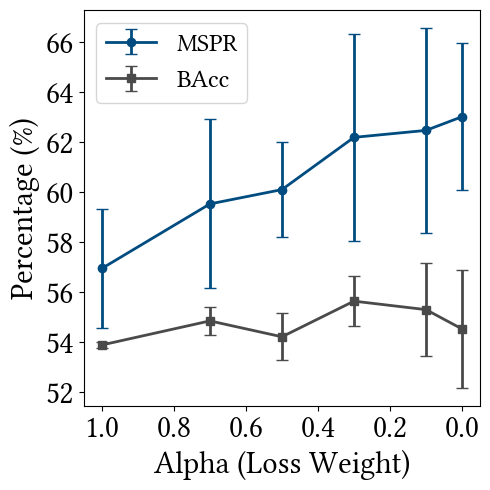

In [ ]:

# MAIN


VARS = [
    "mean_supports_prob_on_refutes",
    "balanced_accuracy"
]

results = collect_results_multi(ALPHA_FILES, VARS)

print("Results:")
print("-" * 40)

for alpha in sorted(results[VARS[0]].keys()):

    msp = results["mean_supports_prob_on_refutes"][alpha].mean() * 100
    bal = results["balanced_accuracy"][alpha].mean() * 100

    print(
        f"alpha={alpha:>4} | "
        f"MSPR={msp:.2f}% | "
        f"BAL={bal:.2f}%"
    )

print("-" * 40)

plot_alpha_curve(results)
